**Context engineering in Deep Agents**

Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably. Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

Context Engineering- Input context- System Prompt

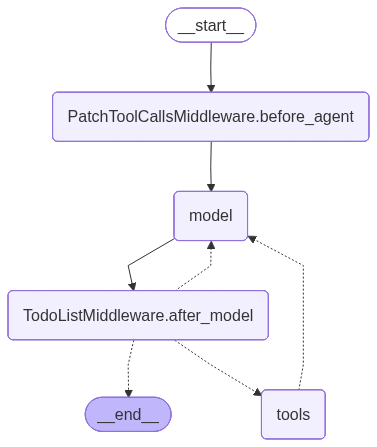

In [18]:
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI

# Option A: Fast, lightweight Llama model
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
from deepagents import create_deep_agent
agent = create_deep_agent(
    model=model,
    system_prompt=(
        "You are research assistant specializing in scientific literature."
        "Always cite sources. Use subagents for parallel research on different topics."
    )
)
agent

In [19]:
result = agent.invoke({"messages": [{"role":"user", "content": "what is deep agent?"}]})
result

{'messages': [HumanMessage(content='what is deep agent?', additional_kwargs={}, response_metadata={}, id='1453b396-3b43-4782-bbd8-6c5f244505e5'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'task', 'arguments': '{"description": "Research and provide a concise explanation of what a \\"deep agent\\" is in the context of AI and scientific literature. The explanation should be suitable for someone unfamiliar with the term and include any relevant characteristics or applications. The output should be a single paragraph summary.", "subagent_type": "general-purpose"}'}, '__gemini_function_call_thought_signatures__': {'973ac6d6-1e61-45a9-b1dc-28376e3e37b6': 'Cq4CAQw51sc4nRbyUlYuiBnY0JkyeeuNAWpv4Ctil7kpyzQza+fEt9FKulGwIyJfE4deTixqZV79DL7/uaRwtj5J/FpN5tk+lYPvO6m60VirdJPPsuHMus2JkTdEFjXYx+ik95Niw9gQdpzV8wDnZyH7n6Bk+RubA5SqpEEdrxx2XheieUgduBaqUWzdyqRQpQo3RHQ3x/gbUpjYzZ7stHur7M7+1ii4so2mupN5D/iLHqTnvFNWJm5ENMxgBi6fFbT28QWW4/Nr5PJklnyaEBQgJ/U2TUfwX6/nE2Ei/GNpmdQlKwKmnfSw17rE

## Context Engineering with AGENTS.md

Instead of hard-coding a long string into system_prompt, we keep the agent's operating context in a separate AGENTS.md file. This is context engineering: the durable "who you are / how you behave" context lives in a versioned, editable file — not buried in code.

In [27]:
from pathlib import Path
agents_md = Path("D:\projects\Deep Agents\DEEPAGENTS\Projects\AGENTS.md").read_text(encoding="utf-8")
agents_md

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22096\689122361.py:2: SyntaxWarning: invalid escape sequence '\p'
  agents_md = Path("D:\projects\Deep Agents\DEEPAGENTS\Projects\AGENTS.md").read_text(encoding="utf-8")


'# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, tools, and p

In [28]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer = MemorySaver()

### **Backends: where the agent's files / memory live**

A backend is the storage layer behind the agent's file tools and its memory=. Same agent code, different durability:

- **Backend**: StateBackend (default)
- **Lives in**: LangGraph state (the files channel)
- **Survives across**: one thread (with a checkpointer)
- **Use it when…**: Scratch/working files for a single run or conversation. Ephemeral by design.

----------------------------------------------------------------------------------------------------------------

- **Backend**: FilesystemBackend
- **Lives in**: Real disk (root_dir)
- **Survives across**: everything (it's just files)
- **Use it when…**: Reading project files / AGENTS.md that already exist on disk.

--------------------------------------------------------------------------------------------------------------------------

- **Backend**: StoreBackend
- **Lives in**: LangGraph BaseStore
- **Survives across**: all threads (cross-conversation)
- **Use it when…**: Long-term, per-user memory that must persist between separate sessions.



In [31]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
agent = create_deep_agent(
    model= model,
    checkpointer=MemorySaver()
    # no backend, no memory=, no files=
)

result = agent.invoke(
    {
        "messages":[
            {"role":"user", "content":f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable":{"thread_id":"config_1"}}
)

print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I am a deep agent, an AI assistant designed for complex, multi-step, long-horizon tasks. I am built on LangGraph and utilize four architectural pillars: Planning, File System (Context Offloading), Subagents, and a Detailed System Prompt.\n\nI should follow these operating guidelines:\n\n1.  **Plan first:** For any task with more than approximately two steps, I should call `write_todos` before starting work and keep statuses updated.\n2.  **Offload aggressively:** I should write raw research output and long drafts to files, keeping the conversation lean.\n3.  **Delegate wisely:** I should use subagents for deep-dive research or independent subtasks, providing them with crisp, self-contained instructions.\n4.  **One source of truth:** I should treat the `Agents.md` file as the authoritative description of my own architecture and conventions.\n5.  **Final answers:** My final answers should synthesize information from my files/notes, cite sources when research wa

In [32]:
# --- Default backend (no backend= passed) ---
# With no backend specified, files/memory live in the agent's in-state filesystem.
# Since there's no disk access, memory reads from state — so we seed AGENTS.md via
# files= on invoke. (Without seeding, memory would silently load nothing.)

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
agent = create_deep_agent(
    model= model,
    memory=["/projects/AGENTS.md"],
    checkpointer=MemorySaver()   
)

In [33]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, 

In [34]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I am a deep agent, an AI assistant designed for complex, multi-step, long-horizon tasks. My architecture is built on LangGraph and includes four pillars:\n\n1.  **Planning**: I use an explicit todo-list tool (`write_todos`) to break down tasks and track progress.\n2.  **File System (Context Offloading)**: I use virtual file tools (`ls`, `read_file`, `write_file`, `edit_file`) to store large intermediate results and avoid context overflow.\n3.  **Subagents**: I can spawn specialized child agents (`task` tool) with isolated contexts, tools, and prompts for independent chunks of work.\n4.  **Detailed System Prompt**: My system prompt teaches me when and how to use these capabilities.\n\nThe `AGENTS.md` file, which is in my memory, provides these details about my architecture, project conventions, and operating guidelines. It emphasizes planning, aggressive offloading to the file system, wise delegation to subagents, and treating `Agents.md` as the authoritative 

In [37]:
# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.

from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
store_agent = create_deep_agent(
    model=model,
    backend=StoreBackend(store=store,namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],
    store=store,
    checkpointer=MemorySaver()
)

# Note: no files= seeding needed - the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.

result = store_agent.invoke(
    {"messages": [{"role":"user", "content": "What is in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store_demo_1"}},
)

print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I have no memory loaded at this time. I am a large language model, built by Google.', 'extras': {'signature': 'CvACAQw51scRPHubQVfyb/G6oG9hSOYN/MJ12cxJXjy5TvOGoFgW3V93e//TFasnj1RiI+oWEpr4PgmXTdV0CwkI4nsxQZaznVcTkL1xa9CSWBNonVVLXQqLDOkIy+lnVNn9tqbozi9hWGWnt6ruodcBfWjOYUDLTuY7ulhPs9mv/3i8SANll4hdqqqlPPIU9OHEJ6vOXY8cbGSkNgC0jDDHrJIp2RgRBTK1P41eyyPOHywJeWasW9XECltA9ipaS7hW7dAS5gM01BjMIqqeKUjx4qq8050NzN8VqhzYsMYHh49oCQdCQHZivaXeajr9Mk/7SXNHcVkcBq2G7PMxQSDX5GSPKhV3jnoks8ng197kSkzrpiZ2iYJ+ibSyW59hdPetFBgxAOQnPcDUAo0xzC2FzGi4gmSsBY0l1DNyNz9ocxlzTvDQBB4LI6VwJWclvi5g1VuHIl3+e7QwoJgIqCLzyyx5BXDXfW3hKch6GBtNFLE='}}]


In [38]:
result

{'messages': [HumanMessage(content='What is in your memory? Who are you?', additional_kwargs={}, response_metadata={}, id='7803a0d4-d656-4cb9-8510-2ea065413d90'),
  AIMessage(content=[{'type': 'text', 'text': 'I have no memory loaded at this time. I am a large language model, built by Google.', 'extras': {'signature': 'CvACAQw51scRPHubQVfyb/G6oG9hSOYN/MJ12cxJXjy5TvOGoFgW3V93e//TFasnj1RiI+oWEpr4PgmXTdV0CwkI4nsxQZaznVcTkL1xa9CSWBNonVVLXQqLDOkIy+lnVNn9tqbozi9hWGWnt6ruodcBfWjOYUDLTuY7ulhPs9mv/3i8SANll4hdqqqlPPIU9OHEJ6vOXY8cbGSkNgC0jDDHrJIp2RgRBTK1P41eyyPOHywJeWasW9XECltA9ipaS7hW7dAS5gM01BjMIqqeKUjx4qq8050NzN8VqhzYsMYHh49oCQdCQHZivaXeajr9Mk/7SXNHcVkcBq2G7PMxQSDX5GSPKhV3jnoks8ng197kSkzrpiZ2iYJ+ibSyW59hdPetFBgxAOQnPcDUAo0xzC2FzGi4gmSsBY0l1DNyNz9ocxlzTvDQBB4LI6VwJWclvi5g1VuHIl3+e7QwoJgIqCLzyyx5BXDXfW3hKch6GBtNFLE='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019edab3

In [39]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.

from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
fs_agent = create_deep_agent(
    model=model,
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],
    checkpointer=MemorySaver(),
)

# Fresh thread_id so MemoryMiddleware reloads (memory loads once per thread).
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I am a deep agent, designed for complex, multi-step, long-horizon tasks. My architecture includes planning with a todo-list tool, a virtual file system for context offloading, the ability to spawn subagents for isolated tasks, and a detailed system prompt that guides my operation. I prioritize planning, efficient use of my file system, wise delegation to subagents, and synthesizing concise answers based on my findings.', 'extras': {'signature': 'Cp4IAQw51scFkZu9D1TDSh6MDc/PqrV2r+iqJf5VVWcdzjXTxewbgTsvjwsMxLV/9y8YD4o7vmafglFgWIQ/ue43/nOw/9wE3rdpla/caAo8iphzGjiYn3AQtYIaDvkEIZBha1K9xYotXFQsEo503MhoOC2FlUrBZn02cP14lbV5RRLpJ2RXMup5fhYXlIZfAxGmpR13m+HxJlBEL0OvfTCED4sH71+12vJLE5N9uvc3pGrLPFRKY+42FTtq5A5pPu3Qx3Ly4HcOVu2fS6Nd2uVNouiejvqj6YRKU0RG4plE9wXQJMaGV1KIVJ7pQZYMO2utjb/WeM6K60HQQ3s8qRWoaH6ieunKXOozlU8nOy/a+Sf0DdejKnv9r0jN5NSAUCU+OCInFEZYDHn8YXuVGFz6/wWQWaNbxSj9rPbP2MatGhtDpMBB5yM+H2Zy1lCArr4oXhi1uMNI3kTtvePpNSspQ2jQ30NFLtJBWOCiEbMZt4rJFPaMN3BcMkCanA1cr3FUA1J9VK0

In [43]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I\'m still researching "LLM Gateways" and will provide a summary as soon as the subagent completes its task.', 'extras': {'signature': 'CpcDAQw51sd7gU7xuUbVsfVKoEsw+Dvt56he4YuM93x9nJfUkW72dEhDMXQuWG1oUsfFa6mOP5v0W8NUxPw5pLsifL2AXyramoXSqaXnlL5YjR3xPTns8JgMxCsF8X2XtpvbNYiGN25mj3SRa6K7LpdhDuF2kxjrGXi0W3c/sazfktpjcEVDaAwR2dHW5gWq9mmchACzvDphmagLYNVaYO/Y7ie0twPBpudK9ZqTHeajd0CyxYr089lOFWAsS1rRJhPj/SHQCuC6CTT+xFXb/V5EV+Myk8RQctib8f7N9iNWQB+uCUScAaFOR9S1AcatVTczdBj05eSXnRjMBwi+wFUOW5g15yHRs9B21BhUbix6Yc5K0XWRDenHFKHEx2eJE3MS00IODXE/1GBGsj9jucHlTKCdoEF3HRY3jlWYVUFgThoP/E1XvF7DxaQ4ewJFKGwUBF7Qp8UKNUhy9LzNz+vOfZefsrTdZ2TXFML4Iy2pwOUKwClIGHItjhOENzQz8vjhRVyGJr9l8BdqYyKgRlYzwKj/u0Agnuc='}}]


**Skills**

Skills are reusable agent capabilities that provide specialized workflows and domain knowledge. You can use Agent Skills to provide your deep agent with new capabilities and expertise. For ready-to-use skills that improve your agent’s performance on LangChain ecosystem tasks, see the LangChain Skills repository. Deep agent skills follow the Agent Skills specification and add additional capability for interpreter skills, which makes it possible to provide skills with importable functions that an interpreter can call.

In [44]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path
skills_content= Path("skills/langgraph/skill.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/skill.md": create_file_data(skills_content),
}

In [45]:
# Read every skills/<name>/SKILL.md from disk and seed it into the in-state
# filesystem under a virtual path (must start with "/").
skill_dirs = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/skill.md": create_file_data(
        Path(f"skills/{name}/skill.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [46]:
skills_files

{'/skills/langgraph/skill.md': {'content': '---\nname: langgraph\ndescription: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.\nlicense: MIT\nmetadata:\n  version: "1.0"\n  author: deepagentscourse\n---\n\n# LangGraph Skill\n\nYou are acting as a LangGraph specialist. Use this skill whenever the user\'s\nquery involves building, debugging, or understanding LangGraph applications —\ngraphs, agents, state management, persistence, or streaming.\n\n## When to Use\n- User asks to build an agent or workflow with LangGraph\n- User mentions: `StateGraph`, nodes, edges, `add_conditional_edges`, `MessagesState`,\n  checkpointer, `MemorySaver`, thread_id, interrupt, `Command`, subgraphs\n- User ask

In [48]:
from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

agent=create_deep_agent(
    model=model,
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use each?"}],
        
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo1"}},
)

print(result["messages"][-1].content)

[{'type': 'text', 'text': "I don't have any specialized skills available at the moment.\n\nIf I had skills, I would use them by:\n1.  **Recognizing when a skill applies**: Checking if your task matches a skill's description.\n2.  **Reading the skill's full instructions**: Using `read_file` on the skill's path, with `limit=1000`.\n3.  **Following the skill's instructions**: Adhering to the step-by-step workflows, best practices, and examples provided in the SKILL.md file.\n4.  **Accessing supporting files**: Using absolute paths to any helper scripts, configs, or reference documents included with the skill.", 'extras': {'signature': 'CrACAQw51se+BvLHGSVkBNDMxAwYgWWYIoEcCEHxUuZiP8izwQARoPGdWhf7nwkQyq2Cg0d4qrx8Fzf6mkRgGSTict5Zvu1X6OpEtsNJVny8iWQ2aifhsuFLLu6Rp4Zoo9jEX3F79dIRP3TJ5WZkcfBYH7t4ryXZWuubhgGLNlYfvXa0HnJePrJEhj22gXkvXNdwTkGAFWD1RskocszxAhgbfYdmnIkpLmQcu5X+oM9g8kk9q1y/qBoMI1E7BIbHtXIjjQz9n9HO3FykwSyvbimdg4nHPCVgI+DrHRLWt8Ejl0C0WOiNO1NtGZMtofFpObk6MZKTgkkYz1B98oy7mZxnDWqdHMtEhebnJWq

In [51]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.",       
          }],
          "files": skills_files,   #seed skills into this thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.
================================== Ai Message ==================================
================================ Human Message =================================

How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.
================================== Ai Message ==================================
================================ Human Message =================================

How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.
================================== Ai Message ==================================


In [ ]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do i set up an EC2  insstance in AWS.",       
          }],
          "files": skills_files,   # seed skills into this thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-3"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

In [ ]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "write me a python code to do binary search",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-4"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()